In [1]:
'''
Notebook for developing one-to-one sensitivity analysis figure
'''

__author__ =  'Christian Dewey'
__date__   =  '29 December 2025'
__version__ = '0.1.0'

import os
import sys
from pathlib import Path

from h5py import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pflotranutils.h5_output.calc.cross_section import CrossSection 

# Add shared module to path
sys.path.insert(0, str(Path.cwd().parent))
#sys.path.insert(0, str(Path(__file__).parent / 'shared'))
from processing.pflotran import PflotranProcessor, Region

# Add results directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'results'))

# Add model-output directory to path
sys.path.insert(0, str(Path.cwd().parent.parent / 'model-output'))

# Add observation data directory to path
OBS_PATH = str(Path.cwd().parent.parent / 'data/observational')


#### Initialize PFLOTRAN results processor

In [2]:
chem_obs_mzt19 = pd.read_csv(OBS_PATH + "/porewater/mz_2019_porewater.csv", parse_dates=['Date'])
chem_obs_mzt18 = pd.read_csv(OBS_PATH + "/porewater/mz_2018_porewater.csv", parse_dates=['Date'])

water_obs_mzt18 = pd.read_csv(OBS_PATH + "/gw-elevs-z/groundwater_elevs_ALL.csv", parse_dates=['Date and time'])

In [49]:
spin_outputs = [
    'mzt18/2026-01-21/2026-01-21_13-48-20/pflotran-mzt18_2026-01-21_13-48-20_spin.h5',
    'mzt18/2026-01-22/2026-01-22_11-09-33/pflotran-mzt18_2026-01-22_11-09-33_spin.h5'
]

simulation_outputs = [
    'mzt18/2026-01-21/2026-01-21_13-48-20/pflotran-mzt18_2026-01-21_13-48-20.h5',
    'mzt18/2026-01-22/2026-01-22_11-09-33/pflotran-mzt18_2026-01-22_11-09-33.h5'
]

components = [
    'Total_HCO3- [M]',
    'Total_SO4-- [M]',
    'Total_Ca++ [M]',
   # 'Total_Fe++ [M]',
    'pH'
]

In [4]:
processor_mzt18_spin_2 = PflotranProcessor(h5_path=spin_outputs[1], 
                         meander='MZ',
                         perpendicular_axis='x')

processor_mzt18 = PflotranProcessor(h5_path=simulation_outputs[1], 
                         meander='MZ',
                         perpendicular_axis='x')

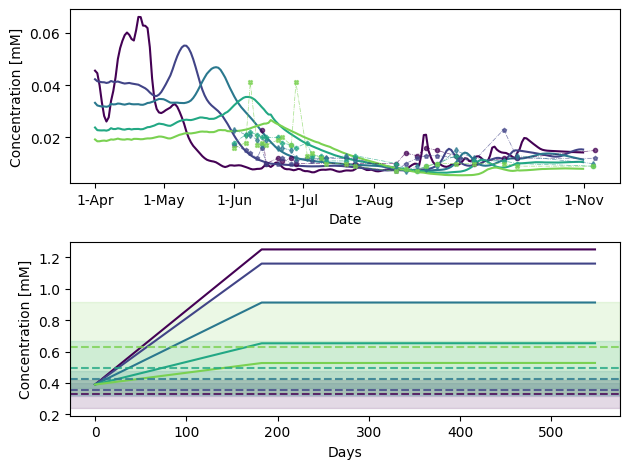

In [5]:
fig, axs = plt.subplots(2,1)
startdate = np.datetime64('2018-04-01')
processor_mzt18.plot_component_histories(component_name='Total_Cl- [M]', startdate=startdate, ax=axs[0], unit='mM', chem_obs=chem_obs_mzt18)
processor_mzt18_spin_2.plot_component_histories(component_name='Total_SO4-- [M]', startdate=None, ax=axs[1], unit='mM', chem_obs=chem_obs_mzt18)
fig.tight_layout()

In [50]:
pp = processor_mzt18
startdate = np.datetime64('2018-05-01')
chem_obs = chem_obs_mzt18
water_obs = water_obs_mzt18 

In [51]:
stats = pp.calculate_kge(                                                                                    
    startdate=startdate,                                                                          
    chem_obs=chem_obs                                                                                       
) 

df = stats['summary']


KGE Summary - 27 components with observations
Component                 Obs               KGE      NSE       RMSE      r      α      β     n
--------------------------------------------------------------------------------
Total_Fe++ [M]            Fe             -0.741   -0.889   8.71e-07 -0.183  0.122  0.073    85
Free_Fe++ [M]             Fe             -0.804   -0.931   8.80e-07 -0.185  0.049  0.029    85
Total_SO4-- [M]           SO4             0.487    0.003   1.91e-04  0.502  0.933  0.893   122
Free_SO4-- [M]            SO4             0.403   -0.134   2.03e-04  0.487  0.791  0.779   122
Total_Ca++ [M]            Ca              0.563   -0.651   5.05e-04  0.696  1.224  1.221   116
Free_Ca++ [M]             Ca              0.633   -0.140   4.20e-04  0.694  1.127  1.157   116
Total_Mg++ [M]            Mg             -0.048   -6.224   2.51e-04  0.389  0.419  0.378   115
Free_Mg++ [M]             Mg             -0.099   -6.808   2.61e-04  0.370  0.376  0.351   115
Total_Na+ [M]    

In [ ]:
def get_component_sub_list(simple_components, component_list):

    component_sublist = []
    for full_component in component_list:
        for simple_component in simple_components:
            if simple_component in full_component:
                component_sublist.append(full_component)

    return component_sublist

component_sub = get_component_sub_list(['Fe',
                                        'HCO3',
                                        'SO4',
                                        'Ca++'], 
                                        df['Component'])

sub_df = df[df['Component'].isin(component_sub)]

print(sub_df)

Kling-Gupta for Total_HCO3- [M]

KGE Summary - 1 components with observations
Component                 Obs               KGE      NSE       RMSE      r      α      β     n
--------------------------------------------------------------------------------
Total_HCO3- [M]           TIC             0.689    0.549   5.23e-04  0.857  1.275  0.979   120

KGE: 0.689
  r (correlation): 0.857
  a (variability): 1.275
  β (bias ratio):  0.979

Kling-Gupta for Total_SO4-- [M]

KGE Summary - 1 components with observations
Component                 Obs               KGE      NSE       RMSE      r      α      β     n
--------------------------------------------------------------------------------
Total_SO4-- [M]           SO4             0.487    0.003   1.91e-04  0.502  0.933  0.893   122

KGE: 0.487
  r (correlation): 0.502
  a (variability): 0.933
  β (bias ratio):  0.893

Kling-Gupta for Total_Ca++ [M]

KGE Summary - 1 components with observations
Component                 Obs               KGE  

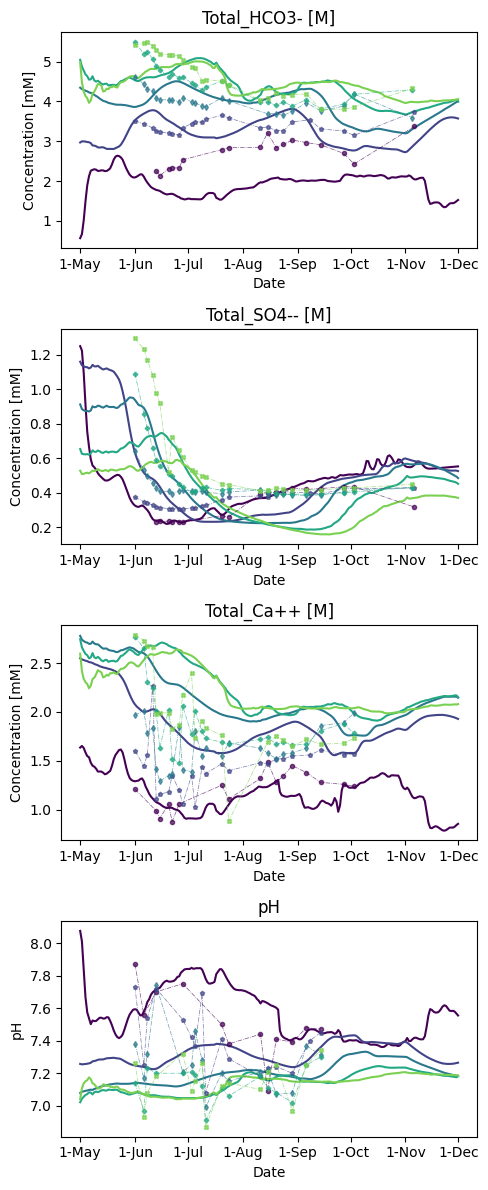

In [52]:
fig, axs = plt.subplots(len(components),1, figsize = (5,12))

for i in range(len(components)):
    print(f'Kling-Gupta for {components[i]}')
    stats = pp.calculate_kge(                                                                   
        component_name=components[i],                                                                              
        startdate=startdate,                                                         
        chem_obs=chem_obs                                                                               
    )                                                                                                  
    print(f"KGE: {stats['kge']:.3f}")                                                                                   
    print(f"  r (correlation): {stats['kge_components']['r']:.3f}")                                                     
    print(f"  a (variability): {stats['kge_components']['alpha']:.3f}")                                                 
    print(f"  β (bias ratio):  {stats['kge_components']['beta']:.3f}\n")   

    axs[i] = pp.plot_component_histories(component_name=components[i], startdate=startdate, ax=axs[i], unit='mM', chem_obs=chem_obs)

    axs[i].set_title(f'{components[i]}')

fig.tight_layout()


--- Validation Stats: Free_HCO3- [M] ---
  R²    = 0.703
  NSE   = 0.086
  KGE   = 0.777
  RMSE  = 7.45e-01
  Bias  = -6.00e-01
  Slope = 0.828
  n     = 120

--- Validation Stats: Total_HCO3- [M] ---
  R²    = 0.735
  NSE   = 0.549
  KGE   = 0.689
  RMSE  = 5.23e-01
  Bias  = -8.17e-02
  Slope = 1.093
  n     = 120

--- Validation Stats: pH ---
  R²    = 0.336
  NSE   = 0.187
  KGE   = 0.573
  RMSE  = 1.88e-01
  Bias  = -3.75e-02
  Slope = 0.535
  n     = 80

--- Validation Stats: Total_Ca++ [M] ---
  R²    = 0.485
  NSE   = -0.651
  KGE   = 0.563
  RMSE  = 5.05e-01
  Bias  = 3.64e-01
  Slope = 0.852
  n     = 116


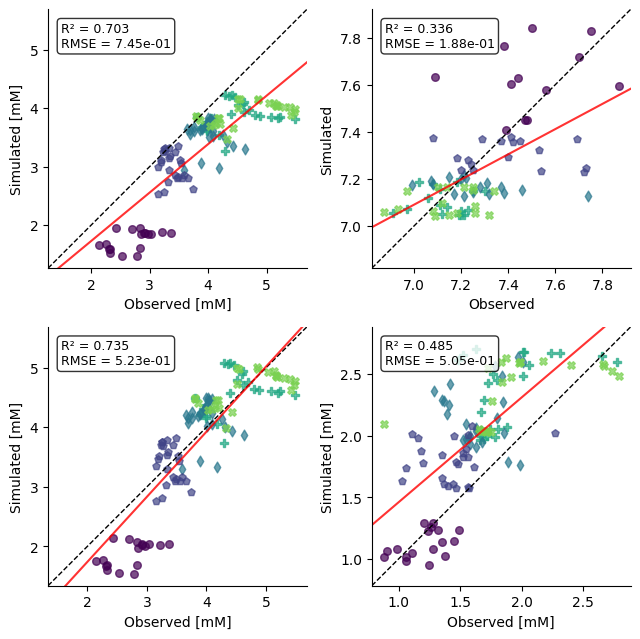

In [48]:
fig, axs = plt.subplots(2,2,figsize=(6.5, 6.5))

ax = axs[0,0]
ax = pp.plot_validation(
    'Free_HCO3- [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax, 
    show_legend=False
)
ax.set_title('')

ax = axs[1,0]
ax = pp.plot_validation(
    'Total_HCO3- [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('')

ax = axs[0,1]
ax = pp.plot_validation(
    'pH',
    startdate=startdate,
    chem_obs=chem_obs,
    ax=ax,
    show_legend=False
)
ax.set_title('')

ax = axs[1,1]
ax = pp.plot_validation(
    'Total_Ca++ [M]',
    startdate=startdate,
    chem_obs=chem_obs,
    unit = 'mM',
    ax=ax,
    show_legend=False
)
ax.set_title('')

sns.despine()

fig.tight_layout()